# EY Water Quality — LightGBM with Feature Importance Pruning
**Two-phase approach:**
1. Train quick models → get per-target feature importance → drop low-importance features
2. Retrain with Optuna on the lean feature sets

This gives each target its own optimized feature set (the running doc recommends this).

In [1]:
# Uncomment if needed
# !pip install optuna lightgbm shap --quiet

In [2]:
import pandas as pd
import numpy as np
import os
import optuna
import shap
import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score
from sklearn.cluster import KMeans
import warnings
import matplotlib.pyplot as plt
import json

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\knich\miniconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\knich\miniconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\knich\miniconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\knich\miniconda3\Lib\site-

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\knich\miniconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\knich\miniconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\knich\miniconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\knich\miniconda3\Lib\site-

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



In [3]:
# ==========================================
# 1. CONFIG
# ==========================================
class Config:
    BASE_DIR = './data'  # <<< CHANGE to your local path
    SEED = 85
    N_FOLDS = 5
    N_OPTUNA_TRIALS = 30
    TARGETS = [
        'Total Alkalinity',
        'Electrical Conductance',
        'Dissolved Reactive Phosphorus'
    ]
    # Importance threshold: features below this cumulative % of total gain get dropped
    # Also: any feature with < MIN_GAIN_PCT of the top feature's gain gets dropped
    MIN_GAIN_PCT = 0.01  # drop if gain < 1% of the best feature's gain

In [4]:
# ==========================================
# 2. ENGINEERING (same as your CatBoost)
# ==========================================
def engineer_features(df):
    temp_df = df.copy()
    if 'nir' in temp_df.columns and 'green' in temp_df.columns:
        temp_df['nir_green_ratio'] = temp_df['nir'] / (temp_df['green'] + 1e-6)
    skewed_feats = ['Popdens_00', 'SOC', 'dist_km']
    for feat in skewed_feats:
        if feat in temp_df.columns:
            temp_df[f'log_{feat}'] = np.log1p(temp_df[feat])
    return temp_df

def prune_features(X, correlation_threshold=0.95):
    X = X.loc[:, X.nunique() > 1]
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > correlation_threshold)]
    print(f"Correlation pruning: dropped {len(to_drop)} features (> {correlation_threshold})")
    return X.drop(columns=to_drop)

In [5]:
# ==========================================
# 3. LOAD DATA & SPATIAL CV
# ==========================================
print("Loading datasets...")
train_full = pd.read_csv(f'{Config.BASE_DIR}/train_ALL+reliability.csv')
test_full = pd.read_csv(f'{Config.BASE_DIR}/test_ALL+reliability.csv')

stations = train_full.groupby(['Latitude', 'Longitude']).size().reset_index()
kmeans = KMeans(n_clusters=Config.N_FOLDS, random_state=Config.SEED, n_init=10)
stations['spatial_cluster'] = kmeans.fit_predict(stations[['Latitude', 'Longitude']])
train_full = train_full.merge(
    stations[['Latitude', 'Longitude', 'spatial_cluster']],
    on=['Latitude', 'Longitude'], how='left'
)

train_eng = engineer_features(train_full)
test_eng = engineer_features(test_full)

# Build initial feature set (same exclusions as CatBoost notebook)
ignore_cols = Config.TARGETS + [
    'Latitude', 'Longitude', 'STAT_ID', 'Sample Date',
    'spatial_cluster', 'geometry', '_merge_terra',
    '_merge_landsat', 'Latitude_glorich',
    'Longitude_glorich', 'date', 'dws_1st', 'Impute_Method'
]
features = [c for c in train_eng.columns if c not in ignore_cols]
X_all = prune_features(train_eng[features])
drop_extra = ['P_modified_same', 'dws_P_reliability']
drop_extra = [c for c in drop_extra if c in X_all.columns]
X_all.drop(columns=drop_extra, inplace=True)

print(f"\nStarting feature count: {X_all.shape[1]}")
print(f"Train rows: {len(X_all)}")

Loading datasets...
Correlation pruning: dropped 7 features (> 0.95)

Starting feature count: 56
Train rows: 9319


---
## Phase 1: Quick models → Feature importance per target

In [6]:
# ==========================================
# 4. PHASE 1 — Train quick LightGBM per target
#    to get feature importance scores
# ==========================================
importance_records = {}  # {target: DataFrame with Feature, Gain, Split}
phase1_scores = {}

quick_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'n_estimators': 500,
    'learning_rate': 0.05,
    'num_leaves': 63,
    'max_depth': 6,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'subsample_freq': 1,
    'verbosity': -1,
    'seed': Config.SEED,
    'n_jobs': -1,
}

groups = train_eng['spatial_cluster']

for target in Config.TARGETS:
    print(f"\n{'='*50}")
    print(f"  Phase 1 — Quick model for: {target}")
    print(f"{'='*50}")
    
    y = train_eng[target].copy()
    y_train = np.log1p(y) if target == 'Dissolved Reactive Phosphorus' else y
    y_train.name = target
    
    # CV to get a baseline score + aggregate importance across folds
    gkf = GroupKFold(n_splits=Config.N_FOLDS)
    fold_scores = []
    gain_accum = np.zeros(X_all.shape[1])
    split_accum = np.zeros(X_all.shape[1])
    
    for fold_i, (tr_idx, va_idx) in enumerate(gkf.split(X_all, y_train, groups=groups)):
        model = lgb.LGBMRegressor(**quick_params)
        model.fit(
            X_all.iloc[tr_idx], y_train.iloc[tr_idx],
            eval_set=[(X_all.iloc[va_idx], y_train.iloc[va_idx])],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
        )
        preds = model.predict(X_all.iloc[va_idx])
        
        if 'Phosphorus' in target:
            score = r2_score(np.expm1(y_train.iloc[va_idx]), np.expm1(preds))
        else:
            score = r2_score(y_train.iloc[va_idx], preds)
        fold_scores.append(score)
        
        gain_accum += model.booster_.feature_importance(importance_type='gain')
        split_accum += model.booster_.feature_importance(importance_type='split')
    
    # Average importance across folds
    fi = pd.DataFrame({
        'Feature': X_all.columns,
        'Gain': gain_accum / Config.N_FOLDS,
        'Split': split_accum / Config.N_FOLDS,
    }).sort_values('Gain', ascending=False).reset_index(drop=True)
    
    # Normalize gain as % of top feature
    fi['Gain_pct'] = fi['Gain'] / fi['Gain'].max() * 100
    fi['Cumulative_Gain_pct'] = fi['Gain'].cumsum() / fi['Gain'].sum() * 100
    
    importance_records[target] = fi
    phase1_scores[target] = np.mean(fold_scores)
    
    print(f"  Phase 1 CV R²: {np.mean(fold_scores):.4f} (+/- {np.std(fold_scores):.4f})")
    print(f"  Total features: {len(fi)}")
    print(f"  Features with Gain > 0: {(fi['Gain'] > 0).sum()}")
    print(f"  Features with < 1% of top gain: {(fi['Gain_pct'] < 1).sum()}")


  Phase 1 — Quick model for: Total Alkalinity
  Phase 1 CV R²: 0.9838 (+/- 0.0084)
  Total features: 56
  Features with Gain > 0: 55
  Features with < 1% of top gain: 51

  Phase 1 — Quick model for: Electrical Conductance
  Phase 1 CV R²: 0.9182 (+/- 0.0707)
  Total features: 56
  Features with Gain > 0: 56
  Features with < 1% of top gain: 48

  Phase 1 — Quick model for: Dissolved Reactive Phosphorus
  Phase 1 CV R²: 0.5854 (+/- 0.2857)
  Total features: 56
  Features with Gain > 0: 55
  Features with < 1% of top gain: 47


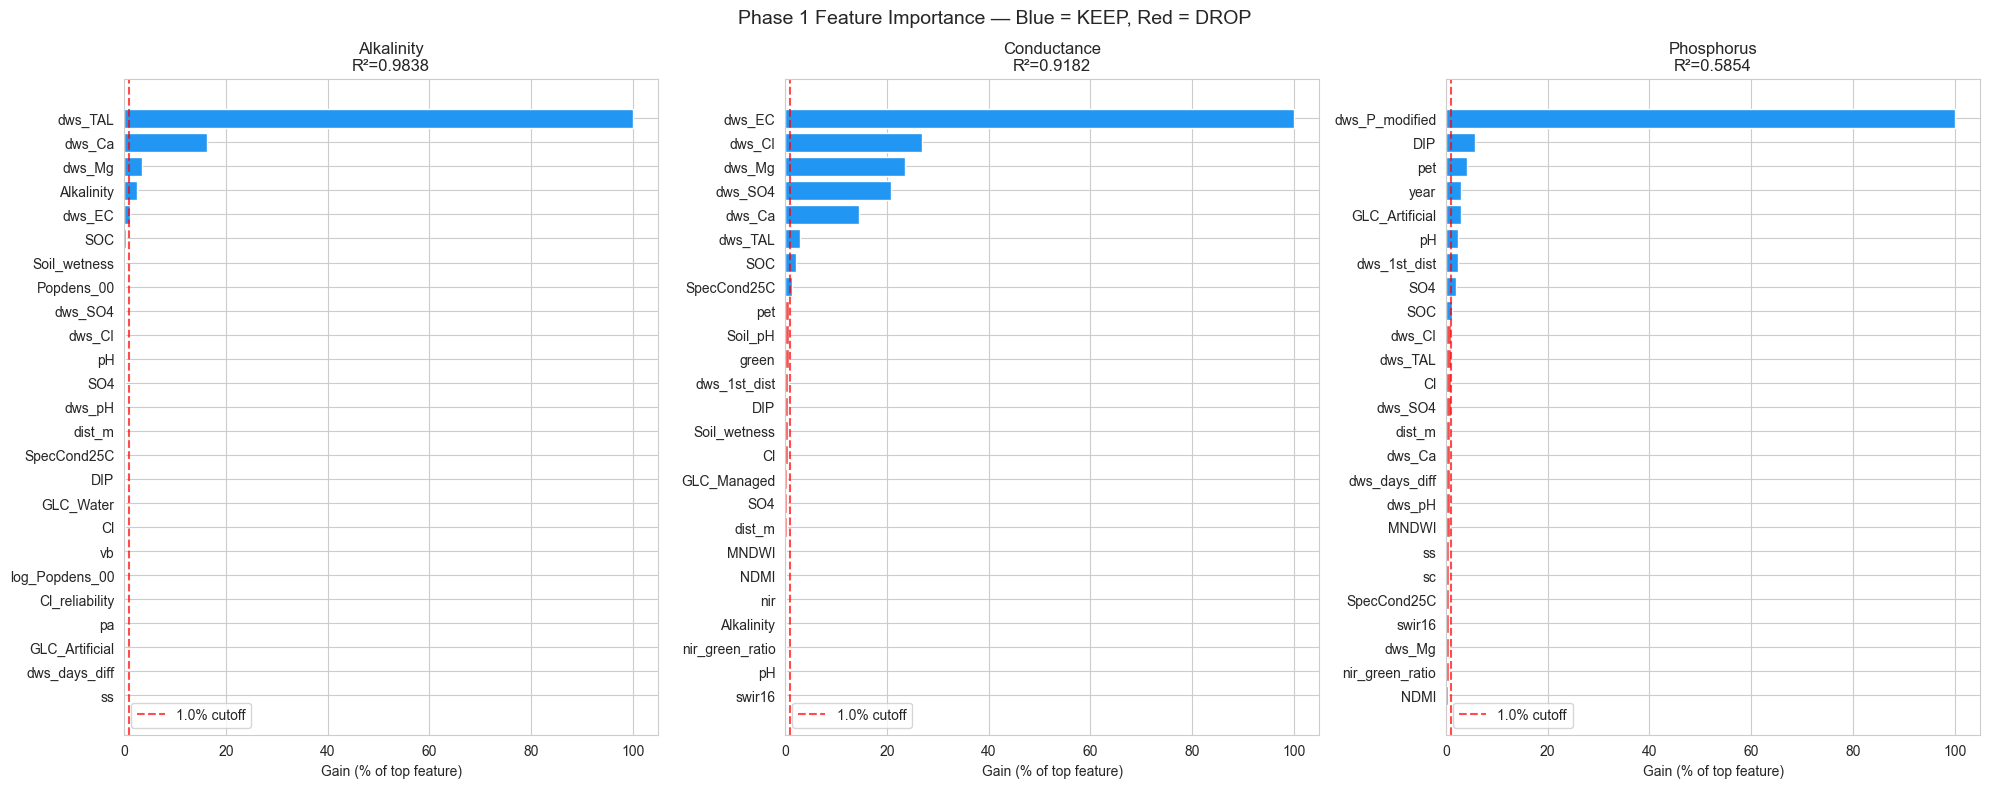

In [7]:
# ==========================================
# 5. VISUALIZE IMPORTANCE & DECIDE CUTS
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for ax, target in zip(axes, Config.TARGETS):
    fi = importance_records[target]
    
    # Show top 20 + highlight the cutoff line
    top = fi.head(25)
    colors = ['#2196F3' if g >= Config.MIN_GAIN_PCT * 100 else '#EF5350' for g in top['Gain_pct']]
    
    ax.barh(top['Feature'][::-1], top['Gain_pct'][::-1], color=colors[::-1])
    ax.axvline(x=Config.MIN_GAIN_PCT * 100, color='red', linestyle='--', alpha=0.7, label=f'{Config.MIN_GAIN_PCT*100}% cutoff')
    ax.set_xlabel('Gain (% of top feature)')
    short_name = target.split()[-1]  # Alkalinity / Conductance / Phosphorus
    ax.set_title(f'{short_name}\nR²={phase1_scores[target]:.4f}')
    ax.legend()

plt.suptitle('Phase 1 Feature Importance — Blue = KEEP, Red = DROP', fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
# ==========================================
# 6. BUILD PER-TARGET PRUNED FEATURE SETS
# ==========================================
pruned_features = {}  # {target: list of feature names to keep}

for target in Config.TARGETS:
    fi = importance_records[target]
    
    # Keep features where gain >= MIN_GAIN_PCT of top feature
    keep = fi[fi['Gain_pct'] >= Config.MIN_GAIN_PCT * 100]['Feature'].tolist()
    dropped = fi[fi['Gain_pct'] < Config.MIN_GAIN_PCT * 100]['Feature'].tolist()
    
    pruned_features[target] = keep
    
    print(f"\n{target}:")
    print(f"  KEEP: {len(keep)} features")
    print(f"  DROP: {len(dropped)} features")
    if dropped:
        print(f"  Dropped: {dropped}")
    # Show what % of total gain we're retaining
    kept_gain = fi[fi['Feature'].isin(keep)]['Gain'].sum()
    total_gain = fi['Gain'].sum()
    print(f"  Retaining {kept_gain/total_gain*100:.1f}% of total gain")


Total Alkalinity:
  KEEP: 5 features
  DROP: 51 features
  Dropped: ['SOC', 'Soil_wetness', 'Popdens_00', 'dws_SO4', 'dws_Cl', 'pH', 'SO4', 'dws_pH', 'dist_m', 'SpecCond25C', 'DIP', 'GLC_Water', 'Cl', 'vb', 'log_Popdens_00', 'Cl_reliability', 'pa', 'GLC_Artificial', 'dws_days_diff', 'ss', 'pet', 'dws_1st_dist', 'va', 'dws_P_modified', 'NDMI', 'nir', 'vi', 'Soil_pH', 'green', 'MNDWI', 'GLC_Managed', 'nir_green_ratio', 'doy_cos', 'sc', 'swir16', 'mt', 'pH_reliability', 'year', 'date_diff_days', 'pb', 'month', 'month_sin', 'SpecCond25C_reliability', 'month_cos', 'SO4_reliability', 'log_dist_km', 'DIP_reliability', 'su', 'Alkalinity_reliability', 'pi', 'wet_season']
  Retaining 98.2% of total gain

Electrical Conductance:
  KEEP: 8 features
  DROP: 48 features
  Dropped: ['pet', 'Soil_pH', 'green', 'dws_1st_dist', 'DIP', 'Soil_wetness', 'Cl', 'GLC_Managed', 'SO4', 'dist_m', 'MNDWI', 'NDMI', 'nir', 'Alkalinity', 'nir_green_ratio', 'pH', 'swir16', 'GLC_Artificial', 'mt', 'Popdens_00', 'vb',

---
## Phase 2: Retrain with Optuna on pruned features

In [9]:
# ==========================================
# 7. OPTUNA OBJECTIVE (same as before)
# ==========================================
def lgbm_objective(trial, X, y, groups, target_name):
    param = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'verbosity': -1,
        'seed': Config.SEED,
        'n_jobs': -1,
        'n_estimators': 1000,
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'subsample_freq': 1,
    }
    
    gkf = GroupKFold(n_splits=Config.N_FOLDS)
    scores = []
    
    for tr_idx, va_idx in gkf.split(X, y, groups=groups):
        model = lgb.LGBMRegressor(**param)
        model.fit(
            X.iloc[tr_idx], y.iloc[tr_idx],
            eval_set=[(X.iloc[va_idx], y.iloc[va_idx])],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
        )
        preds = model.predict(X.iloc[va_idx])
        
        if 'Phosphorus' in target_name:
            scores.append(r2_score(np.expm1(y.iloc[va_idx]), np.expm1(preds)))
        else:
            scores.append(r2_score(y.iloc[va_idx], preds))
    
    return np.mean(scores)

In [ ]:
# ==========================================
# 8. PHASE 2 — Optuna on PRUNED features
# ==========================================
final_preds = {}
models = {}
best_params_all = {}
phase2_scores = {}

for target in Config.TARGETS:
    print(f"\n{'='*50}")
    print(f"  Phase 2 — Optuna for: {target}")
    print(f"  Features: {len(pruned_features[target])} (was {X_all.shape[1]})")
    print(f"{'='*50}")
    
    # Use per-target pruned feature set
    X_target = X_all[pruned_features[target]]
    X_test_target = test_eng[pruned_features[target]]
    
    y = train_eng[target].copy()
    y_train = np.log1p(y) if target == 'Dissolved Reactive Phosphorus' else y
    y_train.name = target
    
    # Optuna
    study = optuna.create_study(direction='maximize')
    study.optimize(
        lambda trial: lgbm_objective(
            trial, X_target, y_train,
            train_eng['spatial_cluster'], target
        ),
        n_trials=Config.N_OPTUNA_TRIALS,
        show_progress_bar=True
    )
    
    best_params_all[target] = study.best_params
    phase2_scores[target] = study.best_value
    print(f"  Best CV R²: {study.best_value:.4f}")
    
    # Final model on full train
    final_params = {
        **study.best_params,
        'n_estimators': 2000,
        'objective': 'regression',
        'metric': 'rmse',
        'verbosity': -1,
        'seed': Config.SEED,
        'n_jobs': -1,
    }
    final_model = lgb.LGBMRegressor(**final_params)
    final_model.fit(X_target, y_train)
    models[target] = final_model
    
    # Save model
    model_path = f'{Config.BASE_DIR}/lgbm_pruned_{target.replace(" ", "_")}.txt'
    final_model.booster_.save_model(model_path)
    
    # Predict
    preds = final_model.predict(X_test_target)
    if target == 'Dissolved Reactive Phosphorus':
        preds = np.expm1(preds)
    final_preds[target] = np.clip(preds, 0, None)


  Phase 2 — Optuna for: Total Alkalinity
  Features: 5 (was 56)


  0%|          | 0/30 [00:00<?, ?it/s]

In [ ]:
# ==========================================
# 9. COMPARE Phase 1 vs Phase 2
# ==========================================
print("\n" + "="*60)
print("  PHASE 1 (all features) vs PHASE 2 (pruned) — CV R²")
print("="*60)
print(f"{'Target':<35} {'All feat':>10} {'Pruned':>10} {'Delta':>10} {'# Feats':>10}")
print("-"*75)

for target in Config.TARGETS:
    p1 = phase1_scores[target]
    p2 = phase2_scores[target]
    delta = p2 - p1
    n_feat = len(pruned_features[target])
    arrow = '\u2191' if delta > 0 else '\u2193' if delta < 0 else '='
    print(f"{target:<35} {p1:>10.4f} {p2:>10.4f} {delta:>+10.4f} {arrow} {n_feat:>8}")

mean_p1 = np.mean(list(phase1_scores.values()))
mean_p2 = np.mean(list(phase2_scores.values()))
print("-"*75)
print(f"{'MEAN':<35} {mean_p1:>10.4f} {mean_p2:>10.4f} {mean_p2-mean_p1:>+10.4f}")

In [ ]:
# ==========================================
# 10. SUBMISSION
# ==========================================
submission_lgb = pd.DataFrame({
    'Latitude': test_full['Latitude'],
    'Longitude': test_full['Longitude'],
    'Sample Date': test_full['Sample Date'],
    'Total Alkalinity': final_preds['Total Alkalinity'],
    'Electrical Conductance': final_preds['Electrical Conductance'],
    'Dissolved Reactive Phosphorus': final_preds['Dissolved Reactive Phosphorus']
})

# Same hybrid DWS override for TAL
dws_tal = test_full['dws_TAL'].values
submission_lgb['Total Alkalinity'] = np.where(
    np.isfinite(dws_tal),
    dws_tal,
    submission_lgb['Total Alkalinity']
)

submission_lgb.to_csv(f'{Config.BASE_DIR}/submission_lgbm_pruned.csv', index=False)
print("LightGBM pruned submission saved.")

In [ ]:
# ==========================================
# 11. ENSEMBLE with CatBoost
# ==========================================
catboost_path = f'{Config.BASE_DIR}/submission_reliabilityOfDWS_temp1_all_features.csv'

if os.path.exists(catboost_path):
    sub_cat = pd.read_csv(catboost_path)
    sub_lgb = submission_lgb.copy()
    
    w_cat, w_lgb = 0.5, 0.5
    
    ensemble = sub_cat[['Latitude', 'Longitude', 'Sample Date']].copy()
    for target in Config.TARGETS:
        ensemble[target] = np.clip(
            w_cat * sub_cat[target] + w_lgb * sub_lgb[target], 0, None
        )
    
    ensemble.to_csv(f'{Config.BASE_DIR}/submission_ensemble_cat_lgb_pruned.csv', index=False)
    print("Ensemble submission saved!")
    
    print("\nModel divergence (mean abs diff):")
    for target in Config.TARGETS:
        diff = np.abs(sub_cat[target] - sub_lgb[target]).mean()
        print(f"  {target}: {diff:.2f}")
else:
    print(f"CatBoost submission not found at {catboost_path}")

In [ ]:
# ==========================================
# 12. FINAL IMPORTANCE ON PRUNED MODELS
# ==========================================
for target in Config.TARGETS:
    model = models[target]
    feats = pruned_features[target]
    
    fi = pd.DataFrame({
        'Feature': feats,
        'Gain': model.booster_.feature_importance(importance_type='gain'),
    }).sort_values('Gain', ascending=False)
    
    print(f"\n{'='*40}")
    print(f"{target} — Final {len(feats)} features")
    print(f"{'='*40}")
    print(fi.to_string(index=False))

In [ ]:
# ==========================================
# 13. SAVE EVERYTHING
# ==========================================
results = {
    'model': 'LightGBM (pruned)',
    'phase1_scores_all_features': {k: float(v) for k, v in phase1_scores.items()},
    'phase2_scores_pruned': {k: float(v) for k, v in phase2_scores.items()},
    'mean_r2_pruned': float(np.mean(list(phase2_scores.values()))),
    'features_per_target': {k: v for k, v in pruned_features.items()},
    'n_features_per_target': {k: len(v) for k, v in pruned_features.items()},
    'best_params': {
        k: {kk: float(vv) if isinstance(vv, float) else vv
            for kk, vv in v.items()}
        for k, v in best_params_all.items()
    }
}

with open(f'{Config.BASE_DIR}/lgbm_pruned_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("All results saved to lgbm_pruned_results.json")